In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_min = float(input("Enter x minimum: "))
x_max = float(input("Enter x maximum: "))
points = int(input("Enter number of points: "))

x = np.linspace(x_min, x_max, points)
print(x)
y = x**2
print(y)

[-10.          -9.97997998  -9.95995996  -9.93993994  -9.91991992
  -9.8998999   -9.87987988  -9.85985986  -9.83983984  -9.81981982
  -9.7997998   -9.77977978  -9.75975976  -9.73973974  -9.71971972
  -9.6996997   -9.67967968  -9.65965966  -9.63963964  -9.61961962
  -9.5995996   -9.57957958  -9.55955956  -9.53953954  -9.51951952
  -9.4994995   -9.47947948  -9.45945946  -9.43943944  -9.41941942
  -9.3993994   -9.37937938  -9.35935936  -9.33933934  -9.31931932
  -9.2992993   -9.27927928  -9.25925926  -9.23923924  -9.21921922
  -9.1991992   -9.17917918  -9.15915916  -9.13913914  -9.11911912
  -9.0990991   -9.07907908  -9.05905906  -9.03903904  -9.01901902
  -8.998999    -8.97897898  -8.95895896  -8.93893894  -8.91891892
  -8.8988989   -8.87887888  -8.85885886  -8.83883884  -8.81881882
  -8.7987988   -8.77877878  -8.75875876  -8.73873874  -8.71871872
  -8.6986987   -8.67867868  -8.65865866  -8.63863864  -8.61861862
  -8.5985986   -8.57857858  -8.55855856  -8.53853854  -8.51851852
  -8.49849

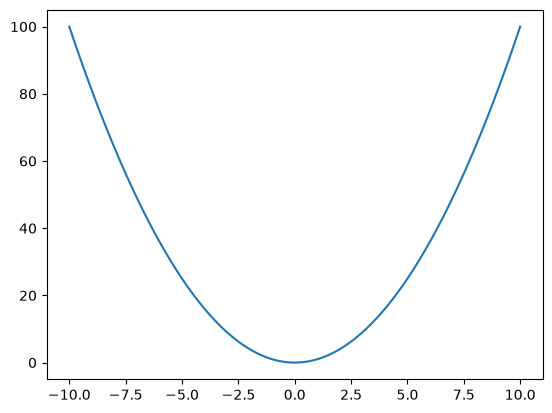

In [4]:
plt.plot(x, y)
plt.show()

In [5]:
import sympy as sp

In [6]:
# equation = "log(x)"
# 
equation = input("Enter an equation in x: ")
x_symbol = sp.symbols("x")

from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

transformations = standard_transformations + (
    implicit_multiplication_application,
)

try:
    expression = parse_expr(
        equation,
        transformations=transformations
    )

    x_values = np.linspace(-10, 10, 100)

    function = sp.lambdify(x_symbol, expression, "numpy")

    y_values = function(x_values)

    y_values = np.asarray(y_values, dtype=float)

    y_values[~np.isfinite(y_values)] = np.nan

    jumps = np.abs(np.diff(y_values))

    threshold = 100

    y_values[:-1][jumps > threshold] = np.nan
    y_values[1:][jumps > threshold] = np.nan
    valid = np.isfinite(y_values)

    x_values = x_values[valid]
    y_values = y_values[valid]
    
    print(y_values)

except Exception:
    print("Invalid equation. Please try again.")
    exit()






[-0.83907153 -0.93116473 -0.98538417 -0.99952453 -0.97301068 -0.90692104
 -0.8039437  -0.66826712 -0.50540974 -0.32199555 -0.12548467  0.07613012
  0.27464844  0.46199582  0.63055219  0.77346177  0.88491192  0.96036956
  0.99676556  0.99261957  0.94810022  0.86501827  0.74675295  0.59811455
  0.4251487   0.23489055  0.03507857 -0.16616018 -0.36064061 -0.54045251
 -0.69828229 -0.82771044 -0.92347268 -0.981674   -0.99994717 -0.97754893
 -0.91539031 -0.81599952 -0.68341913 -0.52304166 -0.34139023 -0.14585325
  0.0556161   0.25482335  0.44366602  0.61446323  0.76026803  0.87515004
  0.95443659  0.99490282  0.99490282  0.95443659  0.87515004  0.76026803
  0.61446323  0.44366602  0.25482335  0.0556161  -0.14585325 -0.34139023
 -0.52304166 -0.68341913 -0.81599952 -0.91539031 -0.97754893 -0.99994717
 -0.981674   -0.92347268 -0.82771044 -0.69828229 -0.54045251 -0.36064061
 -0.16616018  0.03507857  0.23489055  0.4251487   0.59811455  0.74675295
  0.86501827  0.94810022  0.99261957  0.99676556  0

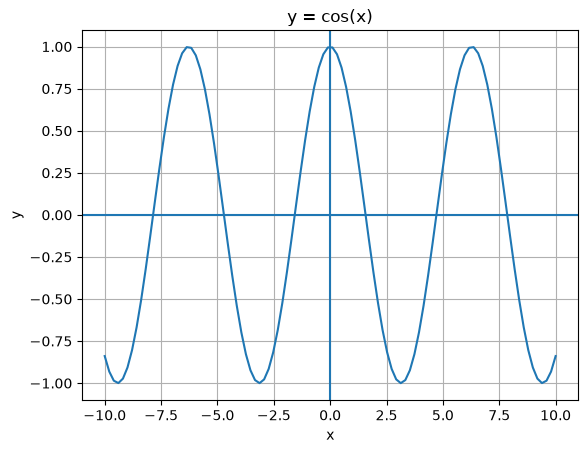

In [7]:
plt.plot(x_values, y_values)

plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.xlabel("x")
plt.ylabel("y")

plt.title(f"y = {expression}")

plt.show()